# Artificial Intelligence & Machine Learning - Task 3
## Model Validation, Overfitting Control & Hyperparameter Tuning

### Objective

In this task, the House Price Prediction system from Task 2 is enhanced by:

- Detecting and controlling overfitting
- Evaluating the model using cross-validation
- Performing hyperparameter tuning using GridSearchCV
- Comparing the optimized model with previous models
- Selecting the final model based on RMSE and R²
- Justifying the final model selection

The California Housing dataset is used for continuity with Task 2.

## step 1: Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [6]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load the California Housing Dataset

In [7]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [
        data.data,
        data.target.rename("HousePrice")
    ],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Create X and Y

In [8]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target:
HousePrice


## Standardize the features

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed.
Scaled data shape: (20640, 8)


## Train and Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


## Train an unrestricted Decision Tree

In [11]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


 ## Measure Training vs Testing performance

In [12]:
train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

print("\nTraining R²:", train_r2)
print("Testing R² :", test_r2)

Training RMSE: 3.0176010694886063e-16
Testing RMSE : 0.7021725586639983

Training R²: 1.0
Testing R² : 0.6237462423352638


## 5-Fold Cross-Validation

In [13]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores

print("RMSE for each fold:")
print(cv_rmse)

print("\nMean CV RMSE:", cv_rmse.mean())
print("Standard Deviation:", cv_rmse.std())

RMSE for each fold:
[0.87752512 0.81754112 0.9051925  0.95581359 0.9247137 ]

Mean CV RMSE: 0.8961572070066897
Standard Deviation: 0.046869258520761396


## Define the parameter grid 

In [14]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

print("Parameter grid:")
print(param_grid)

Parameter grid:
{'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}


## Run GridSearchCV


In [15]:
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Grid search completed.")
print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid.best_score_)

Grid search completed.

Best Parameters:
{'max_depth': 10, 'min_samples_split': 10}

Best Cross-Validation RMSE:
0.6366408923917068


## Get the best model

In [16]:
best_tree = grid.best_estimator_

print("Best Decision Tree:")
print(best_tree)

Best Decision Tree:
DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)


## Evaluate the tuned Decision Tree

In [17]:
y_pred = best_tree.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
tuned_r2 = r2_score(y_test, y_pred)

print("Tuned Decision Tree Results")
print("---------------------------")
print("Test RMSE:", tuned_rmse)
print("Test R²:", tuned_r2)

Tuned Decision Tree Results
---------------------------
Test RMSE: 0.6454300828015771
Test R²: 0.6820992539714815


## Compare all models

In [18]:
# Train Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# Train Ridge Regression
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Evaluate Linear Regression
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

# Evaluate Ridge Regression
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Tuned Decision Tree"
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        tuned_rmse
    ],
    "R²": [
        linear_r2,
        ridge_r2,
        tuned_r2
    ]
})

comparison

,Model,RMSE,R²
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


## Identify the best model

In [20]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]

print("Best Model Based on RMSE:")
print(best_model["Model"])

print("\nRMSE:", best_model["RMSE"])
print("R²:", best_model["R²"])

Best Model Based on RMSE:
Tuned Decision Tree

RMSE: 0.6454300828015771
R²: 0.6820992539714815


# Visualize model performance

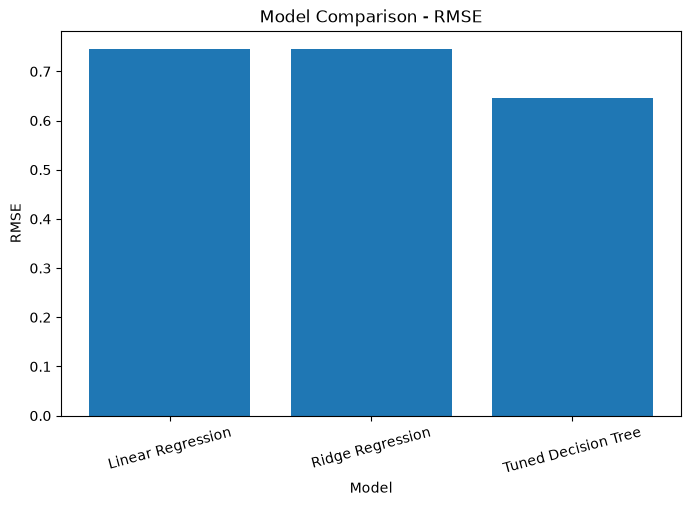

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=15)

plt.show()

## Final Conclusion

The initial unrestricted Decision Tree showed clear signs of overfitting. It achieved an almost zero training RMSE and a training R² of 1.00, while its test RMSE increased to 0.7022 and its test R² decreased to 0.6237.

To obtain a more reliable estimate of model performance, 5-fold cross-validation was performed. The unrestricted Decision Tree achieved a mean cross-validation RMSE of 0.8962 with a standard deviation of 0.0469.

GridSearchCV was then used to tune the Decision Tree hyperparameters. The best combination was:

- `max_depth = 10`
- `min_samples_split = 10`

The tuned model achieved a cross-validation RMSE of 0.6366.

On the held-out test set, the tuned Decision Tree achieved an RMSE of 0.6454 and an R² score of 0.6821. This was better than both Linear Regression (RMSE = 0.7456, R² = 0.5758) and Ridge Regression (RMSE = 0.7456, R² = 0.5758).

Therefore, the Tuned Decision Tree was selected as the final model because it achieved the lowest test RMSE and the highest R² among the evaluated models. Hyperparameter tuning also helped control the complexity of the Decision Tree and improved its ability to generalize to unseen data.